In [13]:
import pandas as pd
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import root_mean_squared_error

In [ ]:
def training_data(N: int = 10, seed: int = 37):
    np.random.seed(seed)
    X = np.random.randint(1, 7, size=(N, 5)).astype(float)
    X_petals = np.where(X == 3, 2, 0) + np.where(X == 5, 4, 0)
    y = X_petals.sum(axis=1).astype(float)

    return X, y

Text(0.5, 1.0, 'Dice Rolls vs. Petals')

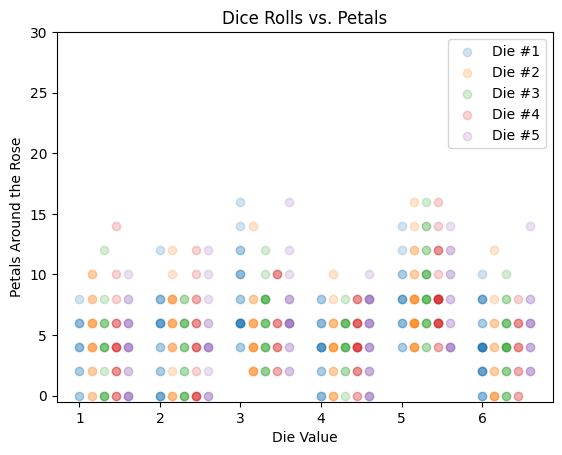

In [57]:
for index in range(X_train.shape[1]):
    plt.scatter(X_train[:100, index] + 0.15*index, y_train[:100], alpha=0.2, label=f"Die #{index+1}")
plt.ylim(-0.5, 30)
plt.legend()
plt.ylabel("Petals Around the Rose")
plt.xlabel("Die Value")
plt.title("Dice Rolls vs. Petals")

In [ ]:
class FCNet(nn.Module):
    def __init__(self, hidden_1: int, hidden_2: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, hidden_1),
            nn.BatchNorm1d(hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, hidden_2),
            nn.BatchNorm1d(hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, 1),
        )

    def forward(self, X):
        return self.net(X)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.1)
        nn.init.constant_(m.bias, 0.0)

In [ ]:
history = []

def train_fc_nn(X, y, *, hidden_1, hidden_2, learning_rate, epochs=1000):
    global history
    history = []

    torch.manual_seed(37)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

    model = FCNet(hidden_1, hidden_2)
    model.apply(init_weights)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_hat = model(X_tensor)
        loss = loss_fn(y_hat, y_tensor)
        loss.backward()
        optimizer.step()

        history.append({
            "epoch": epoch,
            "loss": float(loss.detach().cpu()),
        })

    return model

In [ ]:
X_train, y_train = training_data(1_000, seed=37)
X_valid, y_valid = training_data(1_000, seed=42)


def objective(trial):
    hidden_1 = trial.suggest_int("hidden_1", 8, 1024)
    hidden_2 = trial.suggest_int("hidden_2", 1, 256)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True)

    model = train_fc_nn(
        X_train,
        y_train,
        hidden_1=hidden_1,
        hidden_2=hidden_2,
        learning_rate=learning_rate,
        epochs=5_000,
    )

    model.eval()
    with torch.no_grad():
        y_hat = model(torch.tensor(X_valid, dtype=torch.float32)).numpy().ravel()

    rmse = root_mean_squared_error(y_valid, y_hat)
    accuracy = np.mean(np.rint(y_hat) == y_valid)

    trial.set_user_attr("rmse", rmse)
    trial.set_user_attr("accuracy", accuracy)

    return rmse

# from sklearn.neural_network import MLPRegressor
# def objective2(trial):
#     hidden_1 = trial.suggest_int("hidden_1", 8, 256)
#     hidden_2 = trial.suggest_int("hidden_2", 1, 32)
#     learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True)

#     model = MLPRegressor(
#         hidden_layer_sizes=(hidden_1, hidden_2),
#         activation="relu",
#         solver="adam",
#         learning_rate_init=learning_rate,
#         max_iter=10_000,
#         random_state=37,
#     )

#     model.fit(X_train, y_train)

#     y_hat = model.predict(X_valid)

#     rmse = root_mean_squared_error(y_valid, y_hat)
#     accuracy = np.mean(np.rint(y_hat) == y_valid)

#     trial.set_user_attr("rmse", rmse)
#     trial.set_user_attr("accuracy", accuracy)

#     return rmse

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=37),
)

study.optimize(objective, n_trials=10)

print("Best parameters:")
print(study.best_params)

print("\nBest RMSE:")
print(study.best_value)

print("\nBest accuracy:")
print(study.best_trial.user_attrs["accuracy"])

In [52]:
print("Best parameters:")
print(study.best_params)

print("\nBest RMSE:")
print(study.best_value)

print("\nBest accuracy:")
print(study.best_trial.user_attrs["accuracy"])

Best parameters:
{'hidden_1': 494, 'hidden_2': 46, 'learning_rate': 0.027284343715518806}

Best RMSE:
1.2465166949582627

Best accuracy:
0.267


In [53]:
def train_champion(
    study,
    *,
    N: int = 1_000,
    epochs: int = 10_000,
):
    params = study.best_params

    X_train, y_train = training_data(N, seed=37)

    model = train_fc_nn(
        X_train,
        y_train,
        hidden_1=params["hidden_1"],
        hidden_2=params["hidden_2"],
        learning_rate=params["learning_rate"],
        epochs=epochs,
    )

    return model


model = train_champion(study)

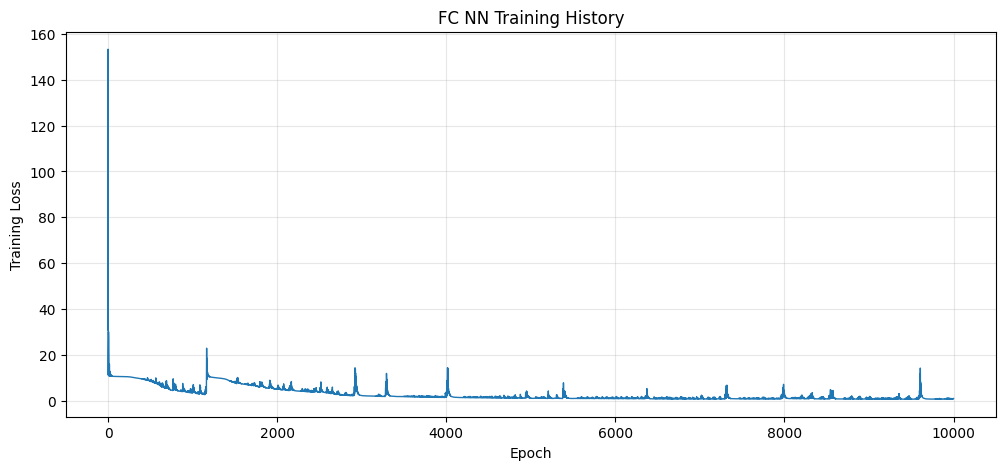

In [60]:
def plot_history():
    history_df = pd.DataFrame(history)

    plt.figure(figsize=(12, 5))
    plt.plot(history_df["epoch"], history_df["loss"], linewidth=1)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("FC NN Training History")
    plt.grid(True, alpha=0.3)
    plt.show()
plot_history()

In [62]:
def evaluate_model(
    model,
    *,
    test_N: int = 10_000,
):
    X_test, y_test = training_data(test_N, seed=42)

    model.eval()

    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_hat = model(X_test_tensor).numpy().ravel()

    y_round = np.rint(y_hat)

    accuracy = np.mean(y_round == y_test)
    accuracy_pm1 = np.mean(np.abs(y_round - y_test) <= 1)

    rmse = root_mean_squared_error(y_test, y_hat)
    mae = np.mean(np.abs(y_hat - y_test))
    bias = np.mean(y_hat - y_test)

    return {
        "accuracy": accuracy,
        "accuracy_pm1": accuracy_pm1,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
    }
evaluate_model(model)

{'accuracy': 0.2827,
 'accuracy_pm1': 0.7598,
 'rmse': 1.2408810065321578,
 'mae': 1.0185412545979022,
 'bias': 0.5252964872777462}

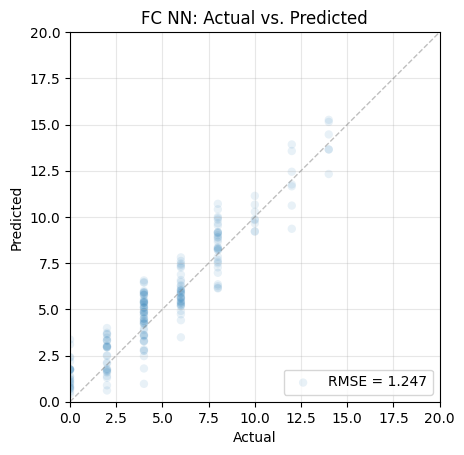

In [54]:
def plot_model_scatter(
    model,
    *,
    test_N: int = 200,
):
    X_test, y_test = training_data(test_N, seed=42)

    model.eval()

    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_hat = model(X_test_tensor).numpy().ravel().astype(float)

    rmse = root_mean_squared_error(y_test, y_hat)

    alpha = min(1.0, 20 / test_N)
    label = f"RMSE = {rmse:.3f}"

    plt.scatter(y_test, y_hat, alpha=alpha, edgecolors="none", label=label)

    plt.axline(
        (0, 0),
        slope=1,
        linestyle="--",
        color="gray",
        alpha=0.5,
        lw=1,
    )

    plt.xlim(0, 20)
    plt.ylim(0, 20)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.legend(loc="lower right")

    plt.title("FC NN: Actual vs. Predicted")

    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, alpha=0.3)

    plt.show()

plot_model_scatter(model)

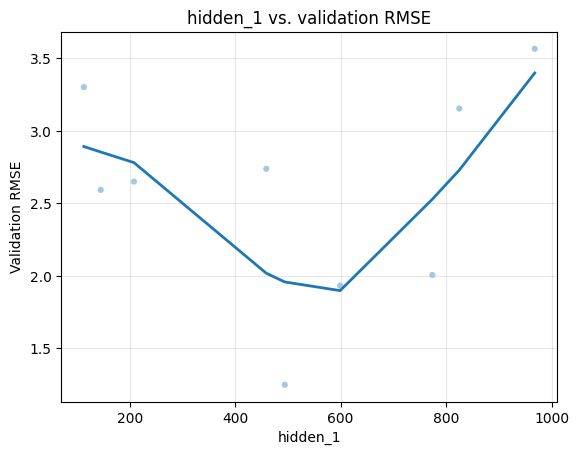

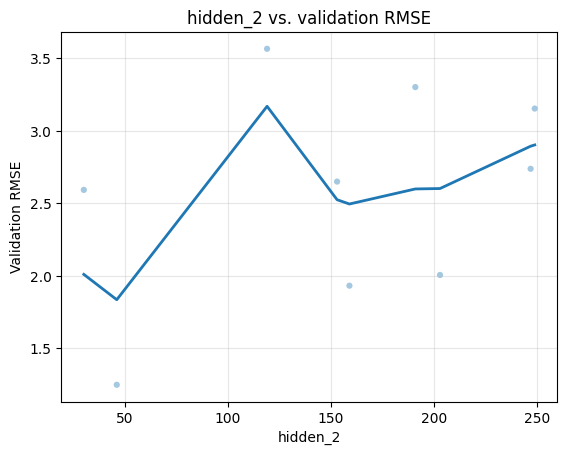

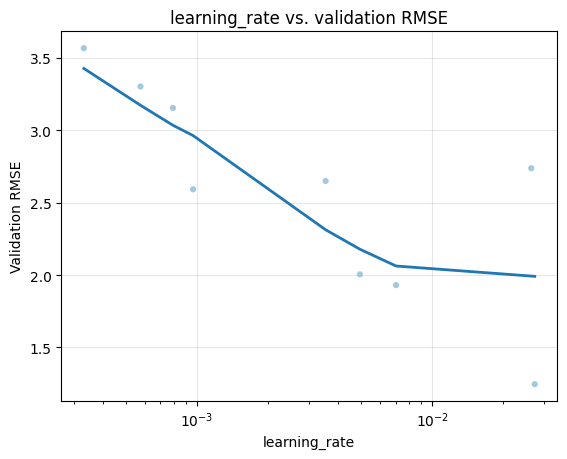

In [55]:
import matplotlib.pyplot as plt

hyperparams = ["hidden_1", "hidden_2", "learning_rate"]

trials_df = study.trials_dataframe()
trials_df = trials_df.rename(columns={
    "params_hidden_1": "hidden_1",
    "params_hidden_2": "hidden_2",
    "params_learning_rate": "learning_rate",
    "value": "target_rmse",
})

for hp in hyperparams:
    plot_df = trials_df[[hp, "target_rmse"]].dropna()

    # Remove worst 10% by validation RMSE
    cutoff = plot_df["target_rmse"].quantile(0.90)
    plot_df = plot_df[plot_df["target_rmse"] <= cutoff]

    x = plot_df[hp].to_numpy()
    y = plot_df["target_rmse"].to_numpy()

    if hp in {"learning_rate"}:
        x_smooth_space = np.log10(x)
    else:
        x_smooth_space = x

    order = np.argsort(x_smooth_space)
    x = x[order]
    y = y[order]
    x_smooth_space = x_smooth_space[order]

    bandwidth = 0.10 * (x_smooth_space.max() - x_smooth_space.min())

    y_smooth = np.empty_like(y)

    for i, xi in enumerate(x_smooth_space):
        weights = np.exp(-0.5 * ((x_smooth_space - xi) / bandwidth) ** 2)
        y_smooth[i] = np.sum(weights * y) / np.sum(weights)

    plt.figure()
    plt.title(f"{hp} vs. validation RMSE")
    plt.xlabel(hp)
    plt.ylabel("Validation RMSE")

    if hp in {"learning_rate"}:
        plt.xscale("log")

    plt.scatter(x, y, alpha=0.4, s=20, edgecolors="none")
    plt.plot(x, y_smooth, linewidth=2)

    plt.grid(True, alpha=0.3)
    plt.show()

In [56]:
def plot_hidden_layer_trials_3d(
    study,
    *,
    target="value",
    title="FC NN Hyperparameter Trials",
):
    trials_df = study.trials_dataframe().rename(columns={
        "params_hidden_1": "hidden_1",
        "params_hidden_2": "hidden_2",
        "value": "target",
    })

    plot_df = trials_df[["hidden_1", "hidden_2", "target"]].dropna()

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=plot_df["hidden_1"],
                y=plot_df["hidden_2"],
                z=plot_df["target"],
                mode="markers",
                marker=dict(
                    size=4,
                    color=plot_df["target"],
                    colorscale="Viridis",
                    opacity=0.75,
                ),
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="hidden_1",
            yaxis_title="hidden_2",
            zaxis_title=target,
        ),
        width=900,
        height=700,
    )

    fig.show()